In [8]:
import numpy as np
import pymc as pm
import arviz as az
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [9]:
sns.set_theme(style="whitegrid")

In [10]:
data = np.array([1, 0, 1, 1, 1, 0, 1, 1, 0, 1])

n = len(data)
heads = data.sum()

print(f"Всего бросков: {n}")
print(f"Орлов: {heads}")

Всего бросков: 10
Орлов: 7


In [11]:
with pm.Model() as coin_model:

    
    theta = pm.Beta("theta", alpha=1, beta=1)

    
    y = pm.Bernoulli("y", p=theta, observed=data)

    trace = pm.sample(
        draws=2000,
        tune=1000,
        target_accept=0.95,
        random_seed=42
    )

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [theta]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 30 seconds.


In [12]:
az.summary(trace)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
theta,0.671,0.131,0.432,0.903,0.002,0.002,3015.0,2392.0,1.0


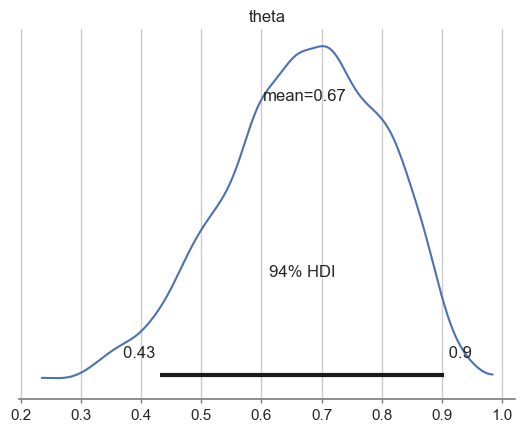

In [6]:
az.plot_posterior(trace, var_names=["theta"])

plt.show()

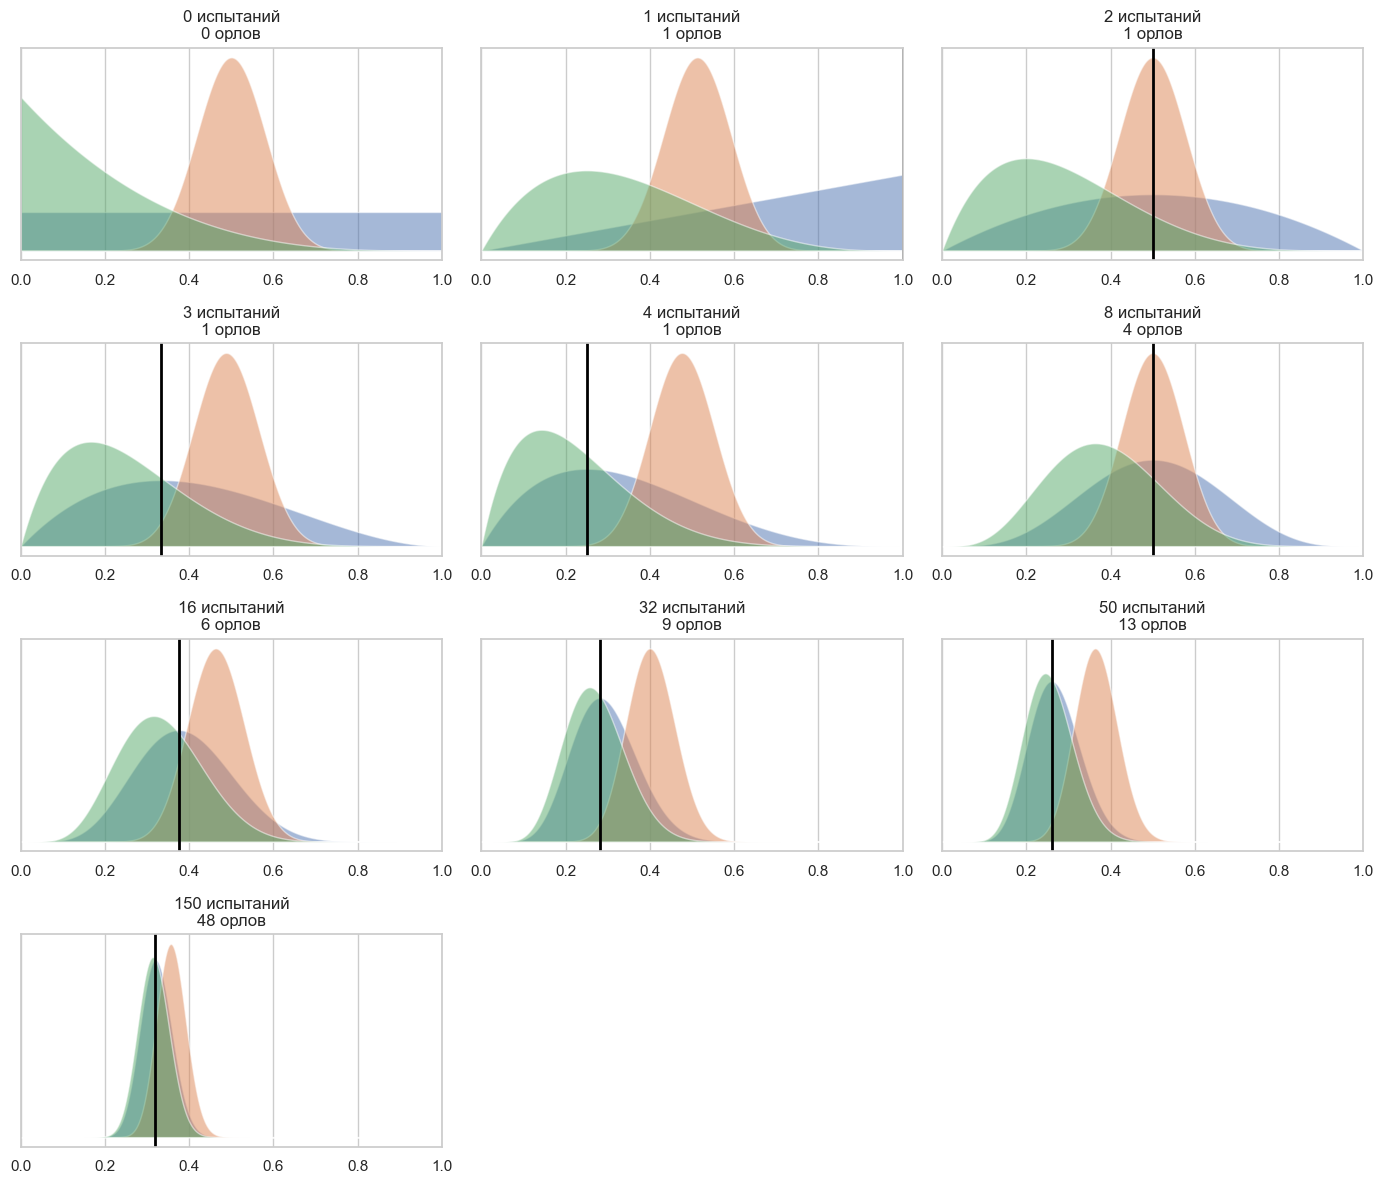

In [7]:
from scipy import stats

x = np.linspace(0, 1, 500)

priors = [
    (1, 1),    
    (20, 20),  
    (1, 4)     
]

experiments = [
    (0, 0),
    (1, 1),
    (2, 1),
    (3, 1),
    (4, 1),
    (8, 4),
    (16, 6),
    (32, 9),
    (50, 13),
    (150, 48)
]

fig, axes = plt.subplots(4, 3, figsize=(14, 12))
axes = axes.flatten()

for ax, (n_trials, n_heads) in zip(axes, experiments):

    for alpha_prior, beta_prior in priors:
        alpha_post = alpha_prior + n_heads
        beta_post = beta_prior + n_trials - n_heads

        y = stats.beta.pdf(x, alpha_post, beta_post)

        ax.fill_between(x, y, alpha=0.5)

    if n_trials > 0:
        ax.axvline(n_heads / n_trials, color="black", linewidth=2)

    ax.set_xlim(0, 1)
    ax.set_yticks([])
    ax.set_title(f"{n_trials} испытаний\n{n_heads} орлов")

for ax in axes[len(experiments):]:
    ax.axis("off")

plt.tight_layout()
plt.show()